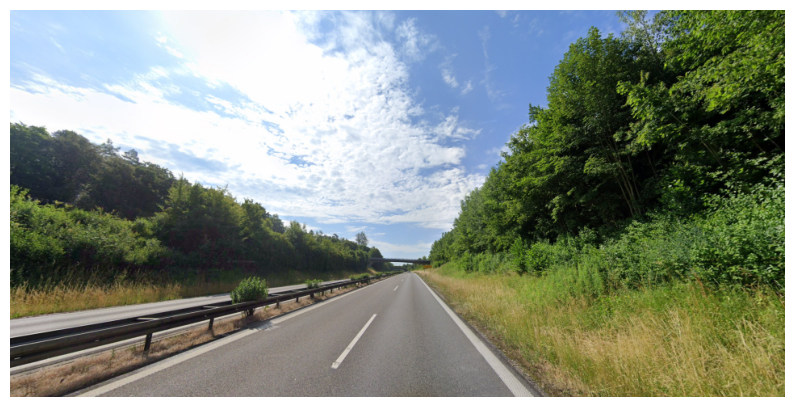

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import time

start = time.time()
img_path = "img/img1.png"
target_height = 480

def resize_preserve_aspect(image, target_height=720):
    h, w = image.shape[:2]
    aspect_ratio = w / h
    target_width = int(target_height * aspect_ratio)
    resized = cv2.resize(image, (target_width, target_height), interpolation=cv2.INTER_AREA)
    return resized


img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = resize_preserve_aspect(img, target_height=target_height)


#show final image
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()



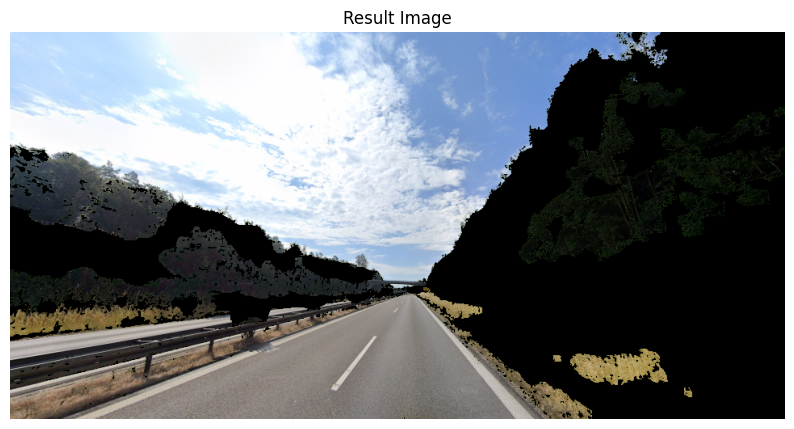

In [2]:
def remove_green_regions(image, green_threshold=40, region_density_threshold=0.5 ):


    # 1. Konvertiere Bild in HSV für robustere Farbdetektion
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Grünbereiche definieren (anpassbar für Threshold)
    lower_green = np.array([60 - green_threshold, 40, 40])
    upper_green = np.array([60 + green_threshold, 255, 255])

    # Maske für grüne Pixel erstellen
    green_mask = cv2.inRange(hsv, lower_green, upper_green)

    # 2. Morphologische Operationen für Regionendichte
    # Lokale Mittelung (Box-Blur) zum Schätzen der "Grün-Dichte"
    kernel_size = 15  # Je größer, desto „größer“ müssen grüne Regionen sein
    density = cv2.blur(green_mask.astype(np.float32)/255, (kernel_size, kernel_size))

    # Regionen mit hoher Dichte heraussuchen
    region_mask = (density >= region_density_threshold).astype(np.uint8) * 255

    # Gesamte betroffene Region vereinheitlichen (optional: closing)
    region_mask = cv2.morphologyEx(region_mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))

    # 3. Maske kombinieren (entweder einzelne grüne Pixel oder ganze Regionen)
    combined_mask = cv2.bitwise_or(green_mask, region_mask)

    # 4. Grüne Regionen schwarz setzen
    result = image.copy()
    result[combined_mask > 0] = [0, 0, 0]

    return result, green_mask, region_mask


green_removed, green_mask, region_mask = remove_green_regions(img, green_threshold=35, region_density_threshold=0.48)

plt.figure(figsize=(10, 10))
plt.imshow(green_removed)
plt.title("Result Image")
plt.axis('off')
plt.show()


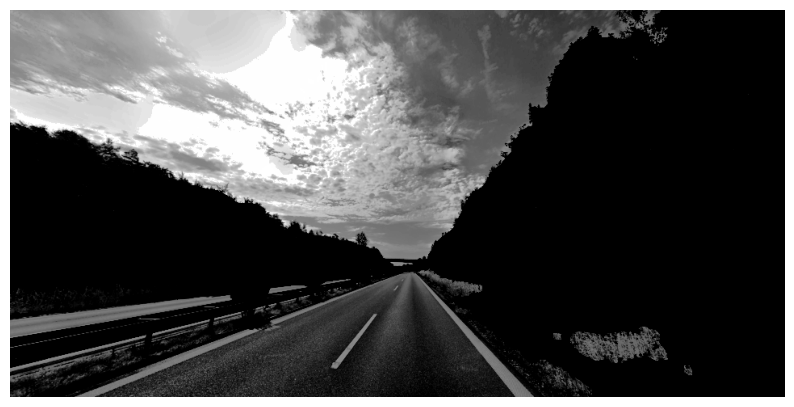

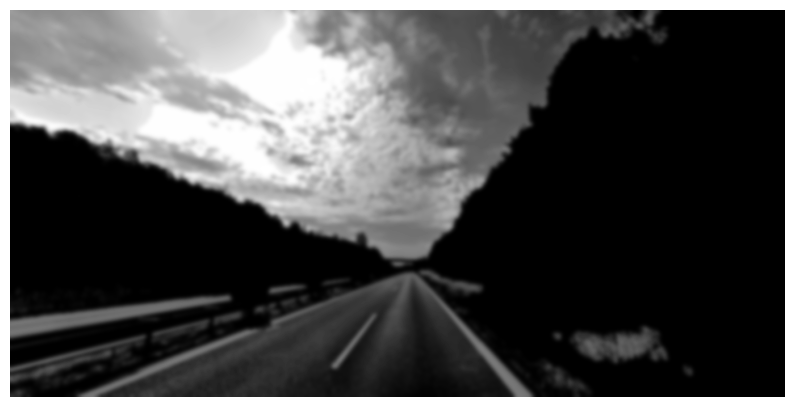

In [3]:
def gray_eq(img):
    img_rgb = img[..., :3]
    gray_image = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)  # ergibt uint8 (0–255)
    
    equalized = cv2.equalizeHist(gray_image)  # ebenfalls uint8
    
    gray_image = equalized.astype(np.float32) / 255.0
    gray_image = np.clip((gray_image - 0.25) / (1.0 - 0.25), 0, 1)
    return gray_image

gray_image = gray_eq(green_removed)
blurred = cv2.GaussianBlur(gray_image, (0, 0), sigmaX=2.5, sigmaY=2.5)

#gray and equalized image
plt.figure(figsize=(10, 10))
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.show()

#blurred 
plt.figure(figsize=(10, 10))
plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.show()

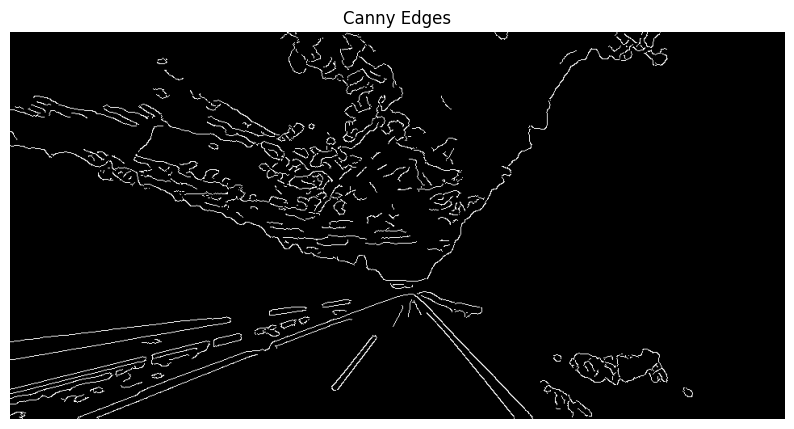

In [4]:
def canny_edge_detection(blurred, low_thresh=0.1, high_thresh=0.2):
    blurred_uint8 = (blurred * 255).astype(np.uint8)

    low_trsh = int(low_thresh * 255)
    high_trsh = int(high_thresh * 255)

    edges = cv2.Canny(blurred_uint8, threshold1=low_trsh, threshold2=high_trsh)
    edges = edges.astype(bool)

    return edges

canny_edges = canny_edge_detection(blurred)

plt.figure(figsize=(10, 10))
plt.imshow(canny_edges, cmap='gray')
plt.title("Canny Edges")
plt.axis('off')
plt.show()

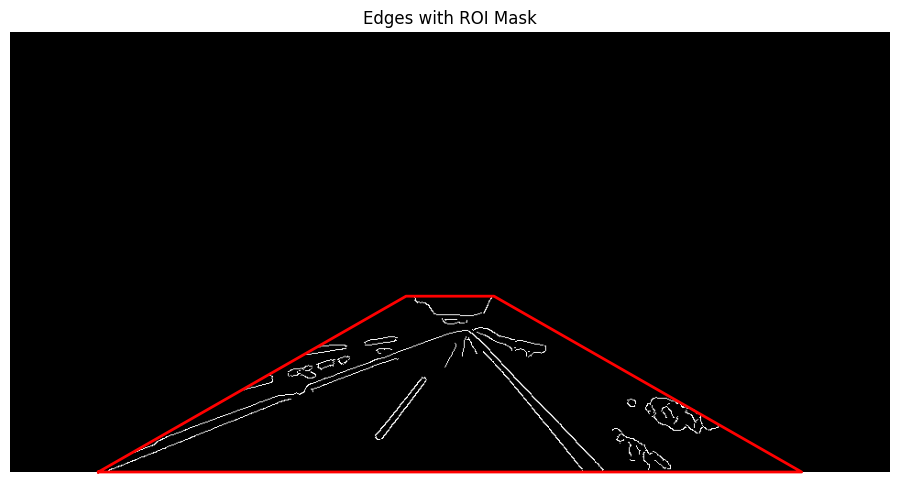

In [5]:
def apply_roi_mask_to_edges(edges, trapezoid_vertices):
    mask = np.zeros_like(edges, dtype=np.uint8)
    polygon = np.array([trapezoid_vertices], dtype=np.int32)
    cv2.fillPoly(mask, polygon, color=1)
    return edges & (mask.astype(bool))

h, w = canny_edges.shape
trapezoid = np.array([
    (int(w * 0.1), int(h)),
    (int(w * 0.45), int(h * 0.6)),
    (int(w * 0.55), int(h * 0.6)),
    (int(w * 0.9), int(h)),
], dtype=np.int32)

edges_roi = apply_roi_mask_to_edges(canny_edges, trapezoid)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(edges_roi, cmap='gray')
trapezoid_closed = np.vstack([trapezoid, trapezoid[0]])
ax.plot(trapezoid_closed[:, 0], trapezoid_closed[:, 1], color='red', linewidth=2)
ax.set_title("Edges with ROI Mask")
ax.axis('off')
plt.show()


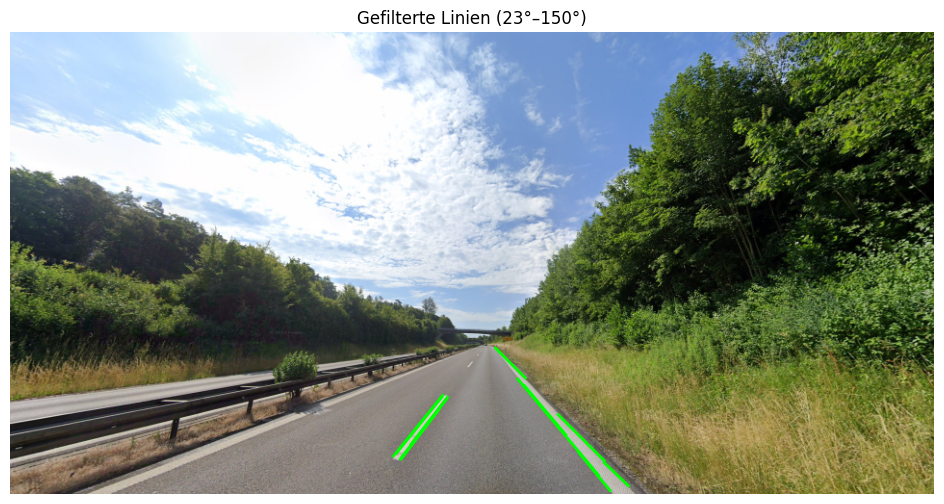

In [6]:
edges_uint8 = (edges_roi.astype(np.uint8)) * 255

raw_lines = cv2.HoughLinesP(
    edges_uint8,
    rho=1,                        # Auflösung: 1 Pixel
    theta=np.pi / 180,           # Winkelauflösung: 1°
    threshold=10,                # Mindestanzahl an Punkten auf Linie
    minLineLength=25,            # Minimale Linienlänge in Pixeln
    maxLineGap=5                 # maximaler Abstand zum Verbinden
)

lines = []
if raw_lines is not None:
    for line in raw_lines:
        x1, y1, x2, y2 = line[0]
        lines.append(((x1, y1), (x2, y2)))

# --- Linien nach Winkel filtern ---
angle_min = 23   # minimale absolute Neigung in Grad
angle_max = 150  # maximale absolute Neigung in Grad

filtered_lines = []
for p0, p1 in lines:
    dx = p1[0] - p0[0]
    dy = p1[1] - p0[1]
    angle = np.degrees(np.arctan2(dy, dx))

    if angle_min < abs(angle) < angle_max:
        filtered_lines.append((p0, p1))

# --- Ergebnis anzeigen ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(img, cmap='gray')

for p0, p1 in filtered_lines:
    ax.plot((p0[0], p1[0]), (p0[1], p1[1]), color='lime', linewidth=2)

plt.title(f"Gefilterte Linien ({angle_min}°–{angle_max}°)")
plt.axis('off')
plt.show()


In [7]:

def average_direction(p0, p1):
    dx = p1[0] - p0[0]
    dy = p1[1] - p0[1]
    return np.degrees(np.arctan2(dy, dx))

def line_midpoint(p0, p1):
    return ((p0[0] + p1[0]) / 2, (p0[1] + p1[1]) / 2)

def group_similar_lines(lines, angle_thresh=5, x_thresh=10):
    groups = []
    for line in lines:
        p0, p1 = line
        angle = average_direction(p0, p1)
        midpoint = line_midpoint(p0, p1)

        matched = False
        for group in groups:
            ga, gm = group['angle'], group['midpoint']
            if abs(angle - ga) < angle_thresh and abs(midpoint[0] - gm[0]) < x_thresh:
                group['lines'].append(line)
                group['angle'] = (group['angle'] + angle) / 2
                group['midpoint'] = ((group['midpoint'][0] + midpoint[0]) / 2,
                                     (group['midpoint'][1] + midpoint[1]) / 2)
                matched = True
                break

        if not matched:
            groups.append({'angle': angle, 'midpoint': midpoint, 'lines': [line]})
    return groups

def fit_line_through_group(group_lines):
    points = []
    for p0, p1 in group_lines:
        points.extend([p0, p1])
    points = np.array(points)

    # Fit Linie y = mx + b
    xs, ys = points[:, 0], points[:, 1]
    if len(xs) < 2:
        return None  # zu wenig Punkte
    poly = np.polyfit(xs, ys, deg=1)
    return poly


def compute_intersection(poly1, poly2):
    m1, b1 = poly1
    m2, b2 = poly2
    if m1 == m2:
        return None  # Parallel
    x = (b2 - b1) / (m1 - m2)
    y = m1 * x + b1
    return (x, y)



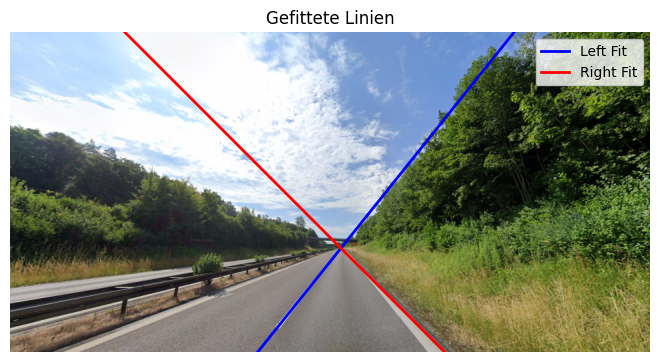

In [8]:

image_center_x = img.shape[1] // 2
left_lines = []
right_lines = []

for p0, p1 in filtered_lines:
    x_avg = (p0[0] + p1[0]) / 2
    if x_avg < image_center_x:
        left_lines.append((p0, p1))
    else:
        right_lines.append((p0, p1))

left_group = group_similar_lines(left_lines)
right_group = group_similar_lines(right_lines)

# Wähle jeweils die größte Gruppe (meiste Linien)
best_left = max(left_group, key=lambda g: len(g['lines']), default=None)
best_right = max(right_group, key=lambda g: len(g['lines']), default=None)

# Line fitten
left_fit = fit_line_through_group(best_left['lines']) if best_left else None
right_fit = fit_line_through_group(best_right['lines']) if best_right else None

# plot left fit and right fit
if left_fit is not None:
    x_left = np.array([0, img.shape[1]])
    y_left = left_fit[0] * x_left + left_fit[1]
    plt.plot(x_left, y_left, color='blue', linewidth=2, label='Left Fit')
if right_fit is not None:
    x_right = np.array([0, img.shape[1]])
    y_right = right_fit[0] * x_right + right_fit[1]
    plt.plot(x_right, y_right, color='red', linewidth=2, label='Right Fit')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Gefittete Linien')
plt.legend()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()



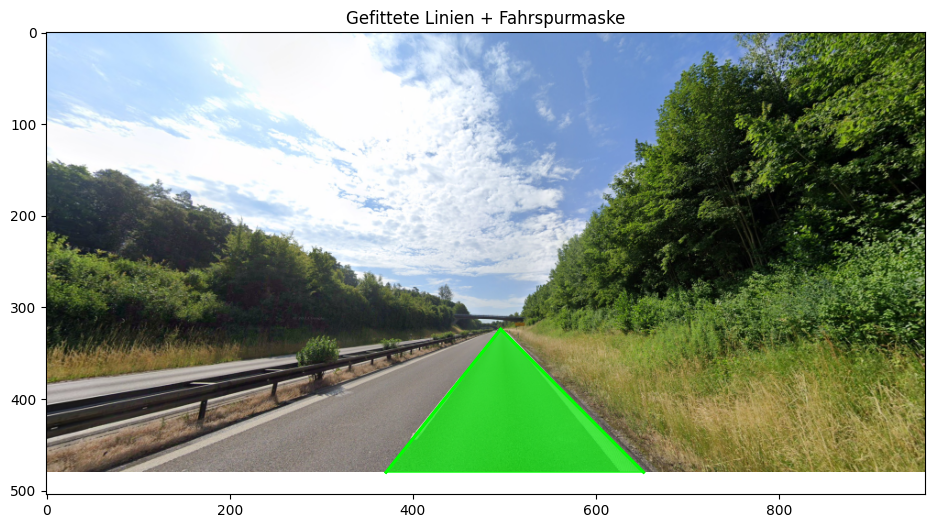

In [9]:
def extrapolate_line(poly, y1, y2):
    # y = mx + b => x = (y - b) / m
    m, b = poly
    x1 = (y1 - b) / m
    x2 = (y2 - b) / m
    return (x1, y1), (x2, y2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(img, cmap='gray')

height = img.shape[0]

if left_fit is not None and right_fit is not None:
    bottom_y = height
    top_y_default = int(height * 0.6)

    intersection = compute_intersection(left_fit, right_fit)
    if intersection and intersection[1] > top_y_default:
        top_y = intersection[1]
    else:
        top_y = top_y_default

    l0, l1 = extrapolate_line(left_fit, bottom_y, top_y)
    r0, r1 = extrapolate_line(right_fit, bottom_y, top_y)

    polygon = Polygon([l0, l1, r1, r0], closed=True, color='lime', alpha=0.4)
    ax.add_patch(polygon)

    ax.plot([l0[0], l1[0]], [l0[1], l1[1]], 'lime', linewidth=2)
    ax.plot([r0[0], r1[0]], [r0[1], r1[1]], 'lime', linewidth=2)

    polygon = Polygon([l0, l1, r1, r0], closed=True, color='lime', alpha=0.4)
    ax.add_patch(polygon)

    ax.plot([l0[0], l1[0]], [l0[1], l1[1]], 'lime', linewidth=2)
    ax.plot([r0[0], r1[0]], [r0[1], r1[1]], 'lime', linewidth=2)

plt.title("Gefittete Linien + Fahrspurmaske")
plt.show()

In [10]:
end = time.time()
print(f"Total execution time: {end - start:.2f} seconds")

Total execution time: 1.22 seconds
